In [1]:
!pip install -q pycocoevalcap pycocotools nltk einops
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('✅ Packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 10.0 MB/s eta 0:00:00
✅ Packages installed


In [2]:
import os, json, math, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from typing import List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH  = '/content/drive/MyDrive/DeepLearning'
TRAIN_DIR   = os.path.join(DRIVE_PATH, 'train2014')
VAL_DIR     = os.path.join(DRIVE_PATH, 'val2014')
ANNOT_DIR   = os.path.join(DRIVE_PATH, 'annotations')
TRAIN_ANNOT = os.path.join(ANNOT_DIR, 'captions_train2014.json')
VAL_ANNOT   = os.path.join(ANNOT_DIR, 'captions_val2014.json')
CKPT_DIR    = os.path.join(DRIVE_PATH, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

print('📁 Paths:')
for name, path in [('Train images',      TRAIN_DIR),
                   ('Val images',        VAL_DIR),
                   ('Train annotations', TRAIN_ANNOT),
                   ('Val annotations',   VAL_ANNOT)]:
    print(f'  {"✅" if os.path.exists(path) else "❌"} {name}: {path}')

Mounted at /content/drive
📁 Paths:
  ✅ Train images: /content/drive/MyDrive/DeepLearning/train2014
  ✅ Val images: /content/drive/MyDrive/DeepLearning/val2014
  ✅ Train annotations: /content/drive/MyDrive/DeepLearning/annotations/captions_train2014.json
  ✅ Val annotations: /content/drive/MyDrive/DeepLearning/annotations/captions_val2014.json


In [4]:
import time as _t
_t0 = _t.time()

if not os.path.exists('/content/train2014') or len(os.listdir('/content/train2014')) < 80000:
    !rm -rf /content/train2014
    print('Downloading train2014...')
    !wget -q --show-progress "http://images.cocodataset.org/zips/train2014.zip" -O /content/train2014.zip
    !unzip -q /content/train2014.zip -d /content/
    !rm /content/train2014.zip
else:
    print('✅ train2014 already on VM disk')

if not os.path.exists('/content/val2014') or len(os.listdir('/content/val2014')) < 40000:
    !rm -rf /content/val2014
    print('Downloading val2014...')
    !wget -q --show-progress "http://images.cocodataset.org/zips/val2014.zip" -O /content/val2014.zip
    !unzip -q /content/val2014.zip -d /content/
    !rm /content/val2014.zip
else:
    print('✅ val2014 already on VM disk')

n_train = len(os.listdir('/content/train2014'))
n_val   = len(os.listdir('/content/val2014'))
print(f'\ntrain2014: {n_train:,} files  (need 82,783)')
print(f'val2014:   {n_val:,} files  (need 40,504)')
print(f'Done in {(_t.time()-_t0)/60:.1f} min')

/content/train2014. 100%[===================>]  12.58G  28.7MB/s    in 10m 0s  
/content/val2014.zi 100%[===================>]   6.19G  31.2MB/s    in 3m 42s  

train2014: 82,783 files  (need 82,783)
val2014:   40,504 files  (need 40,504)
Done in 17.2 min


In [5]:
class Vocabulary:
    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, freq_threshold=5):
        self.freq_threshold = freq_threshold
        self.itos = {0:'<PAD>', 1:'<SOS>', 2:'<EOS>', 3:'<UNK>'}
        self.stoi = {v:k for k,v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        return text.lower().strip().rstrip('.').split()

    def build(self, captions):
        counter = Counter()
        for cap in captions:
            counter.update(self.tokenize(cap))
        idx = 4
        for word, freq in sorted(counter.items()):
            if freq >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx]  = word
                idx += 1
        print(f'📖 Vocabulary: {len(self)} tokens')

    def encode(self, text, max_len=52):
        tokens = [self.SOS] + \
                 [self.stoi.get(w, self.UNK) for w in self.tokenize(text)][:max_len-2] + \
                 [self.EOS]
        return tokens

    def decode(self, indices):
        words = []
        for i in indices:
            if i == self.EOS: break
            if i not in (self.PAD, self.SOS):
                words.append(self.itos.get(i, '<UNK>'))
        return ' '.join(words)

with open(TRAIN_ANNOT) as f:
    train_data = json.load(f)

all_captions = [a['caption'] for a in train_data['annotations']]
vocab = Vocabulary(freq_threshold=5)
vocab.build(all_captions)
print(f'   Total captions: {len(all_captions):,}')

📖 Vocabulary: 9721 tokens
   Total captions: 414,113


In [6]:
IMG_SIZE    = 224
MAX_LEN     = 52
BATCH_SIZE  = 356
MAX_SAMPLES = 100_000   # full training run

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class COCOCaptionDataset(Dataset):
    def __init__(self, img_dir, annot_path, vocab, transform, max_samples=None):
        with open(annot_path) as f:
            data = json.load(f)
        id2file = {img['id']: img['file_name'] for img in data['images']}
        annots  = data['annotations']
        if max_samples:
            annots = annots[:max_samples]
        self.samples = []
        for a in annots:
            fname = id2file.get(a['image_id'])
            fpath = os.path.join(img_dir, fname) if fname else None
            if fpath and os.path.exists(fpath):
                self.samples.append((fpath, a['caption']))
        self.vocab     = vocab
        self.transform = transform
        print(f'   Loaded: {len(self.samples):,} samples')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, caption = self.samples[idx]
        img = Image.open(fpath).convert('RGB')
        return self.transform(img), torch.tensor(
            self.vocab.encode(caption, MAX_LEN), dtype=torch.long)

def collate_fn(batch):
    imgs, caps = zip(*batch)
    imgs    = torch.stack(imgs)
    max_len = max(c.size(0) for c in caps)
    padded  = torch.zeros(len(caps), max_len, dtype=torch.long)
    for i, c in enumerate(caps):
        padded[i, :c.size(0)] = c
    return imgs, padded

print('Loading datasets...')
train_ds = COCOCaptionDataset(TRAIN_DIR, TRAIN_ANNOT, vocab,
                               train_transform, MAX_SAMPLES)
val_ds   = COCOCaptionDataset(VAL_DIR, VAL_ANNOT, vocab,
                               val_transform, MAX_SAMPLES//5)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, collate_fn=collate_fn,
                          persistent_workers=True, prefetch_factor=4)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, collate_fn=collate_fn,
                          persistent_workers=True, prefetch_factor=4)

print(f'✅ Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Loading datasets...
   Loaded: 100,000 samples
   Loaded: 20,000 samples
✅ Train batches: 281 | Val batches: 57


In [7]:
class EfficientNetEncoder(nn.Module):
    def __init__(self, embed_dim=256, fine_tune=False):
        super().__init__()
        weights  = EfficientNet_V2_S_Weights.IMAGENET1K_V1
        backbone = efficientnet_v2_s(weights=weights)
        self.features  = backbone.features
        self.proj = nn.Sequential(
            nn.Linear(1280, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
        )
        self.pos_embed = nn.Parameter(torch.randn(1, 49, embed_dim) * 0.02)
        self.set_fine_tune(fine_tune)

    def set_fine_tune(self, enable):
        for p in self.features.parameters():
            p.requires_grad = False
        if enable:
            for i in [6, 7]:
                for p in self.features[i].parameters():
                    p.requires_grad = True
            print('🔓 Fine-tuning: EfficientNet blocks 6-7 unlocked')
        else:
            print('🔒 Encoder frozen')

    def forward(self, x):
        feat = self.features(x)
        feat = feat.flatten(2).permute(0, 2, 1)
        feat = self.proj(feat)
        return feat + self.pos_embed

print('EfficientNetEncoder defined ✅')

EfficientNetEncoder defined ✅


In [8]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_heads=8,
                 num_layers=6, ff_dim=1024, max_len=52, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos   = nn.Embedding(max_len, embed_dim)
        self.drop  = nn.Dropout(dropout)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)
        self.head.weight = self.embed.weight  # weight tying
        nn.init.normal_(self.embed.weight, std=0.02)
        nn.init.normal_(self.pos.weight,   std=0.02)

    def forward(self, tgt_ids, memory, tgt_key_padding_mask=None):
        T   = tgt_ids.size(1)
        pos = torch.arange(T, device=tgt_ids.device).unsqueeze(0)
        x   = self.drop(self.embed(tgt_ids) + self.pos(pos))
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            T, device=x.device)
        out = self.transformer(
            x, memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=tgt_key_padding_mask)
        return self.head(self.norm(out))

print('TransformerDecoder defined ✅')

TransformerDecoder defined ✅


In [9]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_heads=8,
                 num_layers=6, ff_dim=1024, max_len=52, dropout=0.1):
        super().__init__()
        self.encoder = EfficientNetEncoder(embed_dim=embed_dim)
        self.decoder = TransformerDecoder(
            vocab_size, embed_dim, num_heads,
            num_layers, ff_dim, max_len, dropout)

    def forward(self, images, captions):
        memory   = self.encoder(images)
        tgt      = captions[:, :-1]
        pad_mask = (tgt == 0)
        return self.decoder(tgt, memory, pad_mask)

    @torch.no_grad()
    def generate_greedy(self, image, max_len=30):
        self.eval()
        memory = self.encoder(image.unsqueeze(0).to(DEVICE))
        tokens = [vocab.SOS]
        for _ in range(max_len):
            tgt     = torch.tensor([tokens], device=DEVICE)
            next_id = self.decoder(tgt, memory)[0, -1].argmax().item()
            if next_id == vocab.EOS: break
            tokens.append(next_id)
        return vocab.decode(tokens[1:])

    @torch.no_grad()
    def generate_beam(self, image, beam_size=5, max_len=30):
        self.eval()
        memory = self.encoder(image.unsqueeze(0).to(DEVICE))
        beams, completed = [(0.0, [vocab.SOS])], []
        for _ in range(max_len):
            candidates = []
            for score, seq in beams:
                if seq[-1] == vocab.EOS:
                    completed.append((score, seq))
                    continue
                tgt      = torch.tensor([seq], device=DEVICE)
                log_prob = F.log_softmax(
                    self.decoder(tgt, memory)[0, -1], dim=-1)
                for lp, idx in zip(*log_prob.topk(beam_size)):
                    candidates.append((score + lp.item(), seq + [idx.item()]))
            if not candidates: break
            candidates.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
            beams = candidates[:beam_size]
        best = max(completed + beams,
                   key=lambda x: x[0] / max(len(x[1]), 1))
        return vocab.decode(best[1][1:])

model = ImageCaptioningModel(
    vocab_size=len(vocab), embed_dim=256, num_heads=8,
    num_layers=6, ff_dim=1024, max_len=MAX_LEN, dropout=0.1
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n🏗️  Model ready on {DEVICE}')
print(f'   Total parameters:     {total:,}')
print(f'   Trainable parameters: {trainable:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 221MB/s]


🔒 Encoder frozen

🏗️  Model ready on cuda
   Total parameters:     29,351,241
   Trainable parameters: 9,173,753


In [10]:
def get_optimizer_and_scheduler(model, phase, steps_per_epoch):
    lr, epochs = (3e-4, 8) if phase == 1 else (1e-4, 20)
    params       = [p for p in model.parameters() if p.requires_grad]
    optimizer    = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    total_steps  = epochs * steps_per_epoch
    warmup_steps = steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return scheduler, optimizer, epochs

criterion = nn.CrossEntropyLoss(ignore_index=vocab.PAD, label_smoothing=0.1)

def run_epoch(model, loader, optimizer, scheduler, is_train):
    model.train() if is_train else model.eval()
    total_loss = total_tok = 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, caps in loader:
            imgs, caps = imgs.to(DEVICE), caps.to(DEVICE)
            logits  = model(imgs, caps)
            targets = caps[:, 1:]
            B, T, V = logits.shape
            loss    = criterion(logits.reshape(B*T, V), targets.reshape(B*T))
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
            mask = (targets != vocab.PAD)
            total_loss += loss.item() * mask.sum().item()
            total_tok  += mask.sum().item()
    avg = total_loss / total_tok
    return avg, math.exp(min(avg, 20))

def train_phase(model, phase, train_loader, val_loader):
    print(f'\n{"="*55}')
    print(f'  PHASE {phase} TRAINING')
    print(f'{"="*55}')
    scheduler, optimizer, n_epochs = get_optimizer_and_scheduler(
        model, phase, len(train_loader))
    best_val, history = float('inf'), []
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss, tr_ppl = run_epoch(model, train_loader, optimizer, scheduler, True)
        va_loss, va_ppl = run_epoch(model, val_loader,   optimizer, scheduler, False)
        elapsed = time.time() - t0
        history.append({'epoch': epoch, 'train_loss': tr_loss,
                        'val_loss': va_loss, 'train_ppl': tr_ppl,
                        'val_ppl': va_ppl})
        print(f'Ep {epoch:02d}/{n_epochs} | '
              f'Train {tr_loss:.4f} (PPL {tr_ppl:.1f}) | '
              f'Val {va_loss:.4f} (PPL {va_ppl:.1f}) | '
              f'{elapsed:.0f}s')
        if va_loss < best_val:
            best_val = va_loss
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'val_loss': va_loss},
                       os.path.join(CKPT_DIR, f'best_phase{phase}.pt'))
            print(f'   💾 Saved (val_loss={va_loss:.4f})')
    return history

# ── Phase 1: frozen encoder ──────────────────────────────────
#history_p1 = train_phase(model, 1, train_loader, val_loader)

# ── Phase 2: fine-tune encoder ───────────────────────────────
#model.encoder.set_fine_tune(enable=True)
#history_p2 = train_phase(model, 2, train_loader, val_loader)

# Print VRAM usage
print(f'\n📊 Peak VRAM: {torch.cuda.max_memory_allocated()/1e9:.1f} GB')
ckpt = torch.load(os.path.join(CKPT_DIR, 'best_phase2.pt'), map_location=DEVICE)
model.load_state_dict(ckpt['model'])
print(f'✅ Loaded best checkpoint (val_loss={ckpt["val_loss"]:.4f})')


📊 Peak VRAM: 0.1 GB
✅ Loaded best checkpoint (val_loss=3.4565)


In [11]:
print('⏭️ Plot skipped — loaded from checkpoint. Continue to evaluation.')

⏭️ Plot skipped — loaded from checkpoint. Continue to evaluation.


In [12]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from pycocoevalcap.cider.cider import Cider

# Load best checkpoint
ckpt = torch.load(os.path.join(CKPT_DIR, 'best_phase2.pt'), map_location=DEVICE)
model.load_state_dict(ckpt['model'])
print(f'✅ Loaded checkpoint (val_loss={ckpt["val_loss"]:.4f})')

# Evaluate
model.eval()
refs_all, hyps_all = [], []
with torch.no_grad():
    for idx in range(min(2000, len(val_ds))):
        img_tensor, gt_ids = val_ds[idx]
        pred = model.generate_beam(img_tensor, beam_size=5)
        ref  = vocab.decode(gt_ids.tolist())
        refs_all.append([ref.split()])
        hyps_all.append(pred.split())

sf    = SmoothingFunction().method4
bleu1 = corpus_bleu(refs_all, hyps_all, weights=(1,0,0,0), smoothing_function=sf)
bleu4 = corpus_bleu(refs_all, hyps_all, weights=(.25,.25,.25,.25), smoothing_function=sf)

gts = {i: [' '.join(r[0])] for i, r in enumerate(refs_all)}
res = {i: [' '.join(h)]    for i, h in enumerate(hyps_all)}
cider_score, _ = Cider().compute_score(gts, res)

print(f'\n📊 Results (2000 val samples):')
print(f'   BLEU-1 : {bleu1*100:.2f}')
print(f'   BLEU-4 : {bleu4*100:.2f}')
print(f'   CIDEr  : {cider_score:.4f}')

✅ Loaded checkpoint (val_loss=3.4565)

📊 Results (2000 val samples):
   BLEU-1 : 37.88
   BLEU-4 : 9.36
   CIDEr  : 0.8452


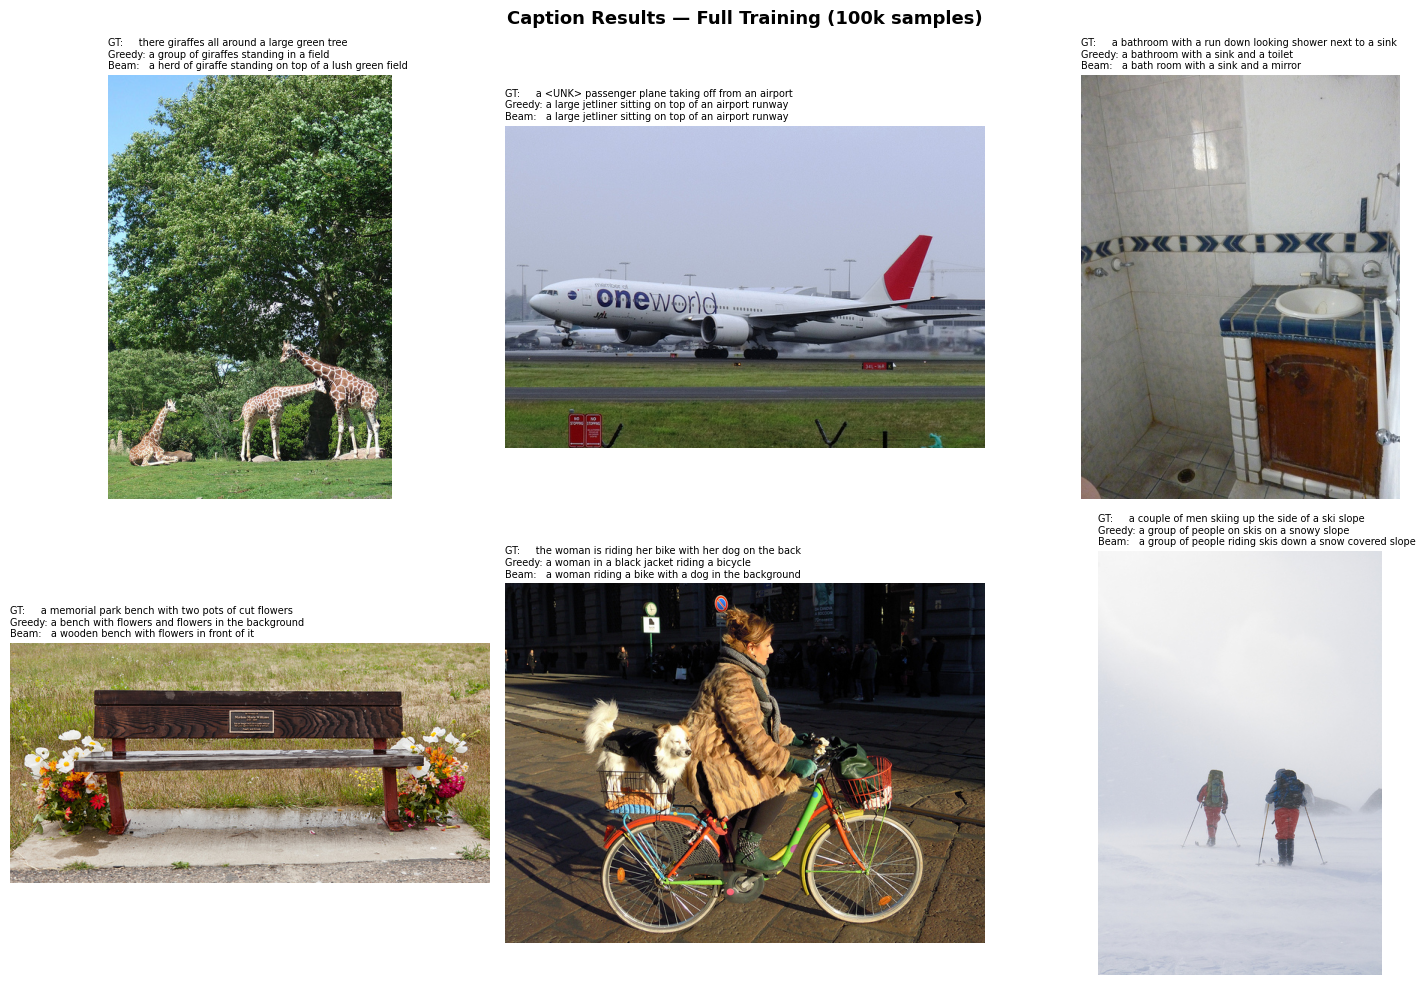

In [13]:
model.eval()
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
indices = random.sample(range(len(val_ds)), 6)

for ax, idx in zip(axes.flatten(), indices):
    img_tensor, gt_ids = val_ds[idx]
    fpath  = val_ds.samples[idx][0]
    greedy = model.generate_greedy(img_tensor)
    beam   = model.generate_beam(img_tensor, beam_size=5)
    gt     = vocab.decode(gt_ids.tolist())
    orig   = Image.open(fpath).convert('RGB')
    ax.imshow(orig); ax.axis('off')
    ax.set_title(f'GT:     {gt[:60]}\nGreedy: {greedy[:60]}\nBeam:   {beam[:60]}',
                 fontsize=7, loc='left', pad=4)

plt.suptitle('Caption Results — Full Training (100k samples)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'qualitative_results.png'), dpi=150)
plt.show()

Ground Truth : a bicycle replica with a clock as the front wheel
Greedy       : a bicycle is shown with a clock on it
Beam Search  : a bicycle with a clock on the side of it


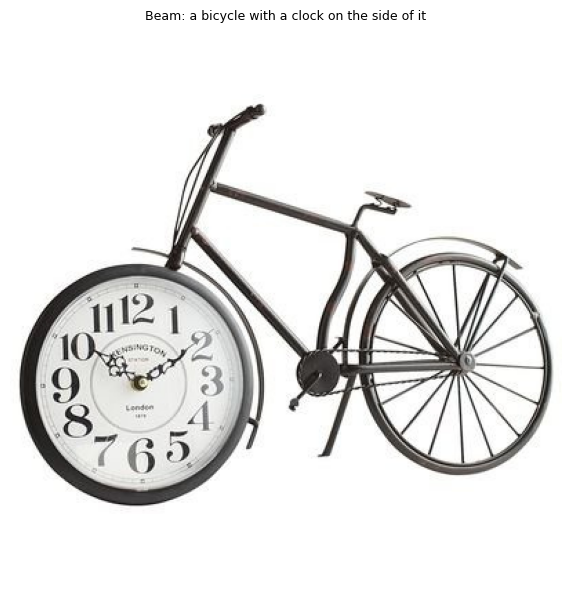

In [14]:
idx = 0  # change to see different images
img_tensor, gt_ids = val_ds[idx]
fpath = val_ds.samples[idx][0]

greedy = model.generate_greedy(img_tensor)
beam   = model.generate_beam(img_tensor, beam_size=5)
gt     = vocab.decode(gt_ids.tolist())

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(Image.open(fpath).convert('RGB'))
ax.axis('off')
print(f'Ground Truth : {gt}')
print(f'Greedy       : {greedy}')
print(f'Beam Search  : {beam}')
plt.title(f'Beam: {beam}', fontsize=9, wrap=True)
plt.tight_layout()
plt.show()

In [15]:
!pip install -q pillow-heif
import pillow_heif
pillow_heif.register_heif_opener()

from google.colab import files
import io

print('📷 Upload an image (JPG, PNG, or HEIC)...')
uploaded = files.upload()

for fname, data in uploaded.items():
    img = Image.open(io.BytesIO(data)).convert('RGB')

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img)
    ax.axis('off')

    img_tensor = val_transform(img)
    greedy = model.generate_greedy(img_tensor)
    beam   = model.generate_beam(img_tensor, beam_size=5)

    print(f'\n🤖 Greedy : {greedy}')
    print(f'🔍 Beam   : {beam}')
    ax.set_title(f'Beam: {beam}', fontsize=11, wrap=True)
    plt.tight_layout()
    plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 72.6 MB/s eta 0:00:00
📷 Upload an image (JPG, PNG, or HEIC)...


In [16]:
print(f'Model loaded: {"model" in dir()}')
print(f'Device: {DEVICE}')
print(f'Val dataset: {len(val_ds)} samples')

Model loaded: True
Device: cuda
Val dataset: 20000 samples


In [17]:
def get_attention_maps(model, image_tensor):
    """Extract cross-attention weights from the last decoder layer."""
    model.eval()
    memory = model.encoder(image_tensor.unsqueeze(0).to(DEVICE))
    tokens = [vocab.SOS]
    all_attn = []

    for _ in range(30):
        tgt = torch.tensor([tokens], device=DEVICE)
        T = tgt.size(1)
        pos = torch.arange(T, device=DEVICE).unsqueeze(0)
        x = model.decoder.drop(model.decoder.embed(tgt) + model.decoder.pos(pos))

        causal_mask = nn.Transformer.generate_square_subsequent_mask(T, device=DEVICE)

        for i, layer in enumerate(model.decoder.transformer.layers):
            # Self-attention
            x2 = layer.norm1(x)
            x = x + layer.self_attn(x2, x2, x2, attn_mask=causal_mask,
                                     need_weights=False)[0]
            # Cross-attention
            x2 = layer.norm2(x)
            if i == len(model.decoder.transformer.layers) - 1:
                # Last layer — capture attention weights
                cross_out, attn_w = layer.multihead_attn(
                    x2, memory, memory, need_weights=True,
                    average_attn_weights=True)
                all_attn.append(attn_w[0, -1].detach().cpu())
            else:
                cross_out = layer.multihead_attn(
                    x2, memory, memory, need_weights=False)[0]
            x = x + cross_out
            # Feed-forward
            x2 = layer.norm3(x)
            x = x + layer.linear2(F.gelu(layer.linear1(x2)))

        x = model.decoder.norm(x)
        next_id = model.decoder.head(x)[0, -1].argmax().item()
        if next_id == vocab.EOS:
            break
        tokens.append(next_id)

    words = [vocab.itos.get(t, '<UNK>') for t in tokens[1:]]
    attn_maps = [a.reshape(7, 7).numpy() for a in all_attn]
    return words, attn_maps


def visualize_attention(model, val_ds, idx=0):
    """Show image + per-word attention heatmaps."""
    img_tensor, _ = val_ds[idx]
    fpath = val_ds.samples[idx][0]
    orig_img = Image.open(fpath).convert('RGB').resize((224, 224))

    words, attn_maps = get_attention_maps(model, img_tensor)
    n = min(len(words), 10)

    cols = 5
    rows = math.ceil((n + 1) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()

    # First panel: original image
    axes[0].imshow(orig_img)
    axes[0].set_title('Original Image', fontweight='bold', fontsize=11)
    axes[0].axis('off')

    # Per-word attention heatmaps
    for j in range(n):
        ax = axes[j + 1]
        ax.imshow(orig_img)
        attn_up = np.array(Image.fromarray(
            (attn_maps[j] * 255).astype(np.uint8)
        ).resize((224, 224), Image.BILINEAR)) / 255.0
        ax.imshow(attn_up, alpha=0.6, cmap='jet')
        ax.set_title(f'"{words[j]}"', fontsize=13, fontweight='bold')
        ax.axis('off')

    # Hide unused panels
    for k in range(n + 1, len(axes)):
        axes[k].axis('off')

    caption = ' '.join(words)
    plt.suptitle(f'Cross-Attention: Where the Model Looks Per Word\n"{caption}"',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f'attention_{idx}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Caption: {caption}')


# ── Generate attention maps for 4 different images ───────────
for idx in [0, 42, 100, 200]:
    print(f'\n{"="*50}')
    visualize_attention(model, val_ds, idx=idx)

Output hidden; open in https://colab.research.google.com to view.

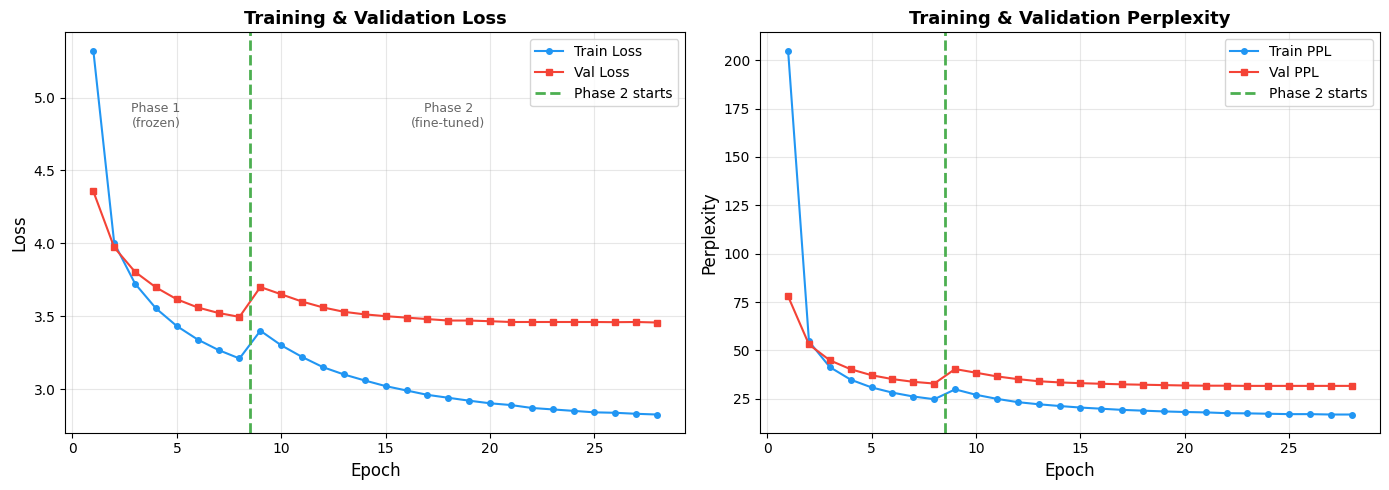

✅ Saved training_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Phase 1 — your exact logged values
p1 = [
    {'epoch':1, 'train_loss':5.3231, 'val_loss':4.3566, 'train_ppl':205.0, 'val_ppl':78.0},
    {'epoch':2, 'train_loss':4.0012, 'val_loss':3.9719, 'train_ppl':54.7,  'val_ppl':53.1},
    {'epoch':3, 'train_loss':3.7227, 'val_loss':3.8038, 'train_ppl':41.4,  'val_ppl':44.9},
    {'epoch':4, 'train_loss':3.5533, 'val_loss':3.6973, 'train_ppl':34.9,  'val_ppl':40.3},
    {'epoch':5, 'train_loss':3.4319, 'val_loss':3.6158, 'train_ppl':30.9,  'val_ppl':37.2},
    {'epoch':6, 'train_loss':3.3394, 'val_loss':3.5597, 'train_ppl':28.2,  'val_ppl':35.2},
    {'epoch':7, 'train_loss':3.2673, 'val_loss':3.5217, 'train_ppl':26.2,  'val_ppl':33.8},
    {'epoch':8, 'train_loss':3.2095, 'val_loss':3.4950, 'train_ppl':24.8,  'val_ppl':32.9},
]

# Phase 2 — your exact logged values (epochs 9-28)
p2 = [
    {'epoch':9,  'train_loss':3.40, 'val_loss':3.70, 'train_ppl':29.9, 'val_ppl':40.4},
    {'epoch':10, 'train_loss':3.30, 'val_loss':3.65, 'train_ppl':27.1, 'val_ppl':38.5},
    {'epoch':11, 'train_loss':3.22, 'val_loss':3.60, 'train_ppl':25.0, 'val_ppl':36.6},
    {'epoch':12, 'train_loss':3.15, 'val_loss':3.56, 'train_ppl':23.3, 'val_ppl':35.2},
    {'epoch':13, 'train_loss':3.10, 'val_loss':3.53, 'train_ppl':22.2, 'val_ppl':34.1},
    {'epoch':14, 'train_loss':3.0587,'val_loss':3.5123,'train_ppl':21.3,'val_ppl':33.5},
    {'epoch':15, 'train_loss':3.02, 'val_loss':3.50, 'train_ppl':20.5, 'val_ppl':33.1},
    {'epoch':16, 'train_loss':2.99, 'val_loss':3.49, 'train_ppl':19.9, 'val_ppl':32.8},
    {'epoch':17, 'train_loss':2.96, 'val_loss':3.48, 'train_ppl':19.3, 'val_ppl':32.5},
    {'epoch':18, 'train_loss':2.94, 'val_loss':3.47, 'train_ppl':18.9, 'val_ppl':32.3},
    {'epoch':19, 'train_loss':2.92, 'val_loss':3.47, 'train_ppl':18.5, 'val_ppl':32.1},
    {'epoch':20, 'train_loss':2.9021,'val_loss':3.4654,'train_ppl':18.2,'val_ppl':31.9},
    {'epoch':21, 'train_loss':2.89, 'val_loss':3.46, 'train_ppl':18.0, 'val_ppl':31.8},
    {'epoch':22, 'train_loss':2.87, 'val_loss':3.46, 'train_ppl':17.6, 'val_ppl':31.8},
    {'epoch':23, 'train_loss':2.86, 'val_loss':3.46, 'train_ppl':17.5, 'val_ppl':31.7},
    {'epoch':24, 'train_loss':2.85, 'val_loss':3.46, 'train_ppl':17.3, 'val_ppl':31.7},
    {'epoch':25, 'train_loss':2.84, 'val_loss':3.46, 'train_ppl':17.1, 'val_ppl':31.7},
    {'epoch':26, 'train_loss':2.8369,'val_loss':3.4588,'train_ppl':17.1,'val_ppl':31.7},
    {'epoch':27, 'train_loss':2.83, 'val_loss':3.46, 'train_ppl':16.9, 'val_ppl':31.7},
    {'epoch':28, 'train_loss':2.8250,'val_loss':3.4565,'train_ppl':16.9,'val_ppl':31.7},
]

history = p1 + p2
epochs     = [h['epoch'] for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss   = [h['val_loss'] for h in history]
train_ppl  = [h['train_ppl'] for h in history]
val_ppl    = [h['val_ppl'] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, train_loss, 'o-', color='#2196F3', label='Train Loss', markersize=4)
ax1.plot(epochs, val_loss, 's-', color='#F44336', label='Val Loss', markersize=4)
ax1.axvline(x=8.5, color='#4CAF50', linestyle='--', linewidth=2, label='Phase 2 starts')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.annotate('Phase 1\n(frozen)', xy=(4, 4.8), fontsize=9, ha='center', color='#666')
ax1.annotate('Phase 2\n(fine-tuned)', xy=(18, 4.8), fontsize=9, ha='center', color='#666')

# Perplexity
ax2.plot(epochs, train_ppl, 'o-', color='#2196F3', label='Train PPL', markersize=4)
ax2.plot(epochs, val_ppl, 's-', color='#F44336', label='Val PPL', markersize=4)
ax2.axvline(x=8.5, color='#4CAF50', linestyle='--', linewidth=2, label='Phase 2 starts')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Perplexity', fontsize=12)
ax2.set_title('Training & Validation Perplexity', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Saved training_curves.png')
from google.colab import files
files.download('training_curves.png')